<a href="https://colab.research.google.com/github/shanto736/digital-marketing/blob/main/notebook0967cfcb59.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Business Objective**


The aim of this project is to predict which  ***customers will convert*** (make a purchase or take the desired action) from digital marketing campaigns.
This will help companies focus on the right customers and use their marketing budget more effectively.


# About
The dataset used in this project is the [Digital Marketing Campaign Dataset ](https://www.kaggle.com/datasets/rabieelkharoua/predict-conversion-in-digital-marketing-dataset/data)from Kaggle.


The dataset consists of 8,000 rows and 20 columns

Features

Demographic Information
* CustomerID: Unique identifier for each customer.
* Age: Age of the customer.Gender: Gender of the customer (Male/Female).
* Income: Annual income of the customer in USD.Marketing-specific


VariablesCampaignChannel: The channel through which the marketing campaign is delivered (Email, Social Media, SEO, PPC, Referral).

* CampaignType: Type of the marketing campaign (Awareness, Consideration, Conversion, Retention).
* AdSpend: Amount spent on the marketing campaign in USD.ClickThroughRate: Rate at which customers click on the marketing content.
* ConversionRate: Rate at which clicks convert to desired actions (e.g., purchases).
* AdvertisingPlatform: Confidential.AdvertisingTool: Confidential.


Customer Engagement Variables

* WebsiteVisits: Number of visits to the website.
* PagesPerVisit: Average number of pages visited per session.
* TimeOnSite: Average time spent on the website per visit (in minutes).
* SocialShares: Number of times the marketing content was shared on social media.
* EmailOpens: Number of times marketing emails were opened.
* EmailClicks: Number of times links in marketing emails were clicked.

Historical Data

* PreviousPurchases: Number of previous purchases made by the customer.
* LoyaltyPoints: Number of loyalty points accumulated by the customer.

Target Variable
* Conversion: Binary variable indicating whether the customer converted (1) or not (0).




# Data Exploration

**2.1 Load the Data**

Load the dataset


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv("/content/digital_marketing_campaign_dataset.csv",header=0)
df


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,15995,21,Male,24849,Email,Awareness,8518.308575,0.243792,0.116773,23,9.693602,14.227794,70,13,6,7,286,IsConfid,ToolConfid,0
7996,15996,43,Female,44718,SEO,Retention,1424.613446,0.236740,0.190061,49,9.499010,3.501106,52,13,1,5,1502,IsConfid,ToolConfid,0
7997,15997,28,Female,125471,Referral,Consideration,4609.534635,0.056526,0.133826,35,2.853241,14.618323,38,16,0,3,738,IsConfid,ToolConfid,1
7998,15998,19,Female,107862,PPC,Consideration,9476.106354,0.023961,0.138386,49,1.002964,3.876623,86,1,5,7,2709,IsConfid,ToolConfid,1


# Display the first 5 rows of the dataset

In [3]:
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


# 2.2 Initial Data Inspection

**Inspecting the Dataset**


Use df.shape, df.info(), and df.describe() to inspect the dataset's size, data types, and summary statistics:



In [4]:
df.shape


(8000, 20)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [6]:
df.describe()


,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


# 2.3 Check for Duplicate Values



In [7]:
df.duplicated().sum()


np.int64(0)

# 2.4 Column Names in the Dataset



In [8]:
df.columns


Index(['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel',
       'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate',
       'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares',
       'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints',
       'AdvertisingPlatform', 'AdvertisingTool', 'Conversion'],
      dtype='object')

# 2.5 Check for Missing Values


In [9]:
df.isnull().sum()


,0
CustomerID,0
Age,0
Gender,0
Income,0
CampaignChannel,0
CampaignType,0
AdSpend,0
ClickThroughRate,0
ConversionRate,0
WebsiteVisits,0


This checks for the number of missing values in each feature to determine how to handle them, such as imputation or removing incomplete rows.

Result: No missing values were found in the dataset.

# Summary of Data Exploration

From the initial data exploration, we found that:

No missing values: This allows us to proceed with the analysis without needing to handle missing data.
No duplicate values: This ensures the dataset is of high quality for building models.
The dataset is well-structured and contains relevant features for the project's objectives.
The next step is to perform deeper analysis, such as exploring relationships between features and preparing the data for building Machine Learning models.



# 3. Data Cleaning
Since the CustomerID feature is merely a customer identifier and has no relevance to the analysis or Machine Learning model,


In [10]:
del_col = ['CustomerID']
df_clean = df.drop(del_col, axis=1)

In [11]:
df = df_clean
df_clean.columns

Index(['Age', 'Gender', 'Income', 'CampaignChannel', 'CampaignType', 'AdSpend',
       'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit',
       'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks',
       'PreviousPurchases', 'LoyaltyPoints', 'AdvertisingPlatform',
       'AdvertisingTool', 'Conversion'],
      dtype='object')

# Channel and campaign type distribution

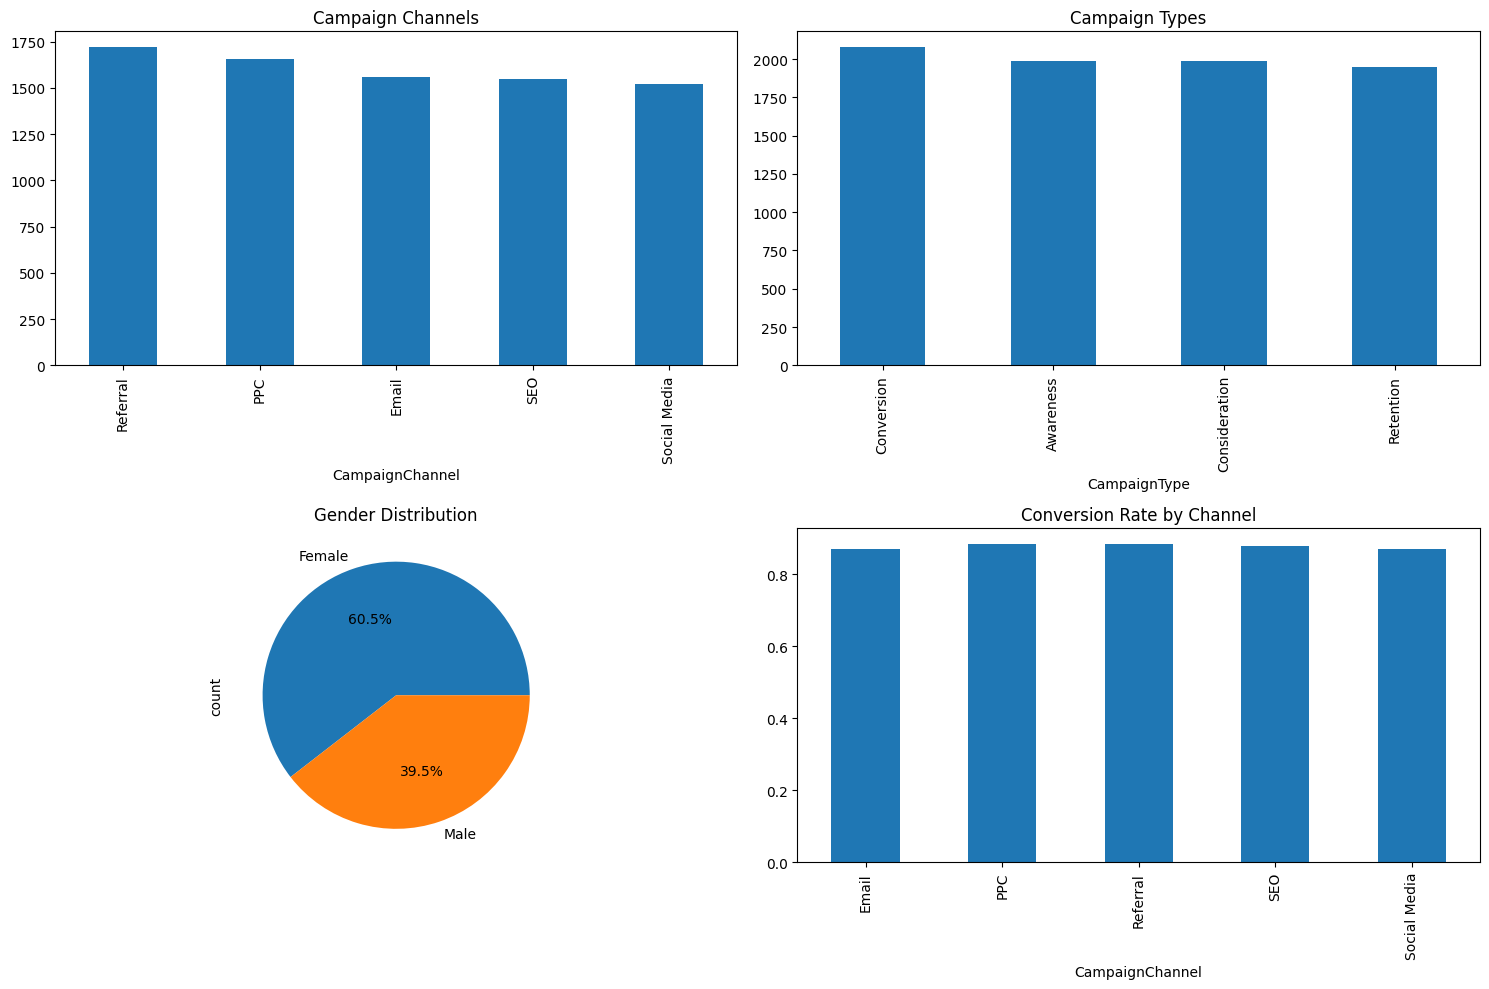

=== CONVERSION BY CHANNEL ===
                 count   sum      mean  conversion_rate
CampaignChannel                                        
Email             1557  1355  0.870263         0.870263
PPC               1655  1461  0.882779         0.882779
Referral          1719  1518  0.883072         0.883072
SEO               1550  1359  0.876774         0.876774
Social Media      1519  1319  0.868334         0.868334


In [12]:
import matplotlib.pyplot as plt

# Channel and campaign type distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df['CampaignChannel'].value_counts().plot(kind='bar', ax=axes[0,0], title='Campaign Channels')
df['CampaignType'].value_counts().plot(kind='bar', ax=axes[0,1], title='Campaign Types')
df['Gender'].value_counts().plot(kind='pie', ax=axes[1,0], title='Gender Distribution', autopct='%1.1f%%')

# Conversion by channel
conv_by_channel = df.groupby('CampaignChannel')['Conversion'].agg(['count', 'sum', 'mean'])
conv_by_channel['conversion_rate'] = conv_by_channel['mean']
conv_by_channel['conversion_rate'].plot(kind='bar', ax=axes[1,1], title='Conversion Rate by Channel')

plt.tight_layout()
plt.show()

print("=== CONVERSION BY CHANNEL ===")
print(conv_by_channel)


# Spend and performance analysis


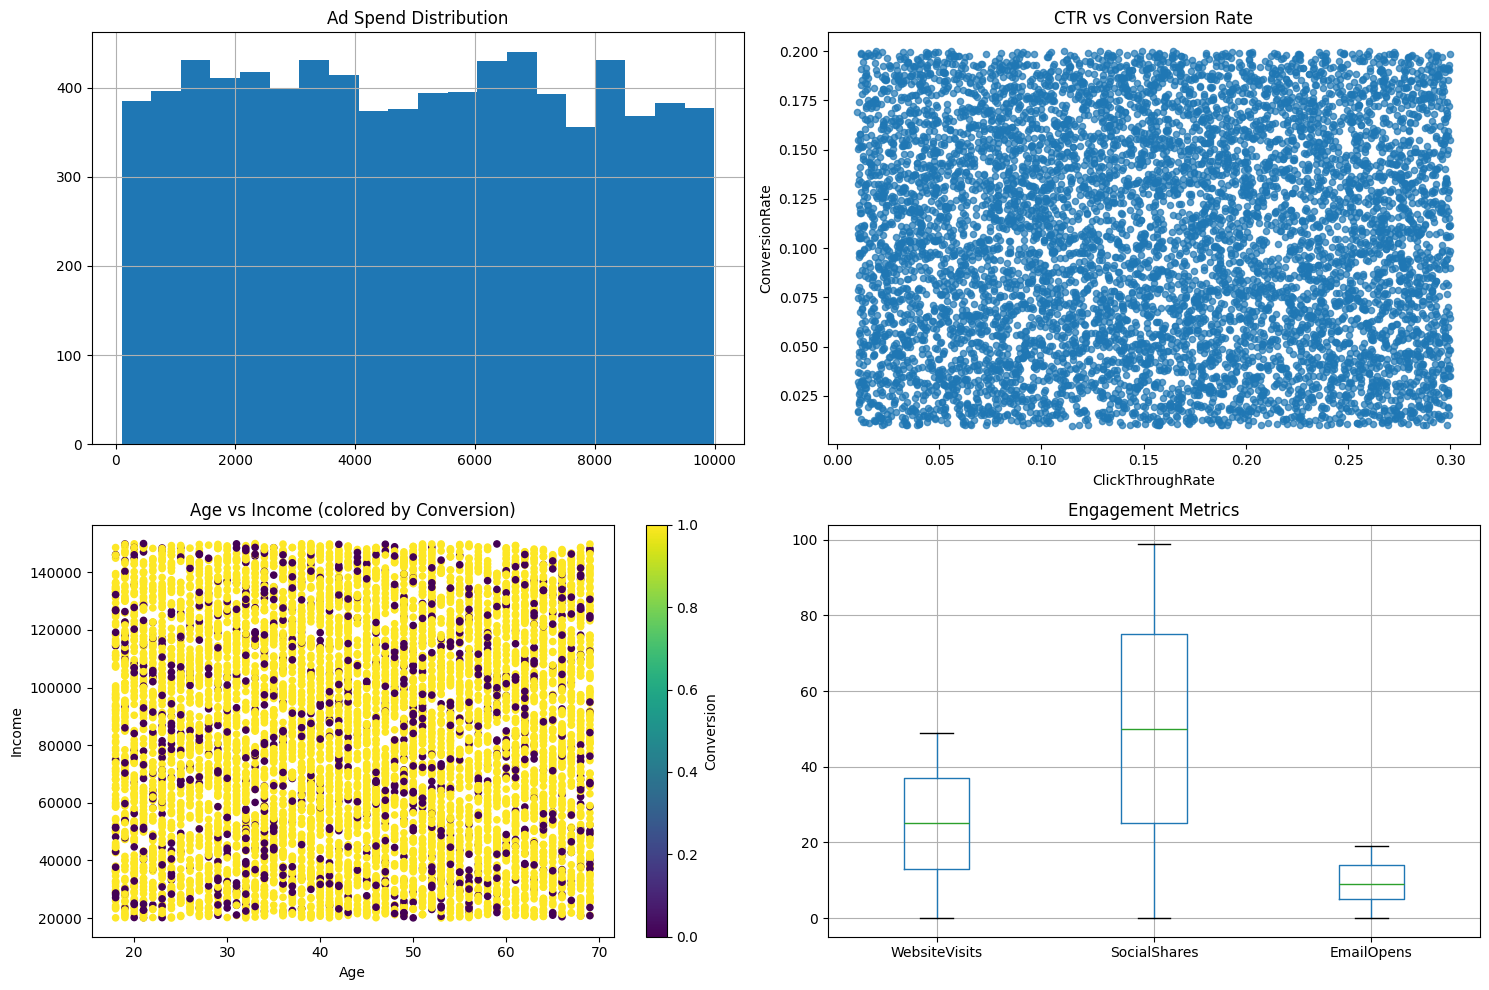

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Ad spend distribution
df['AdSpend'].hist(bins=20, ax=axes[0,0])
axes[0,0].set_title('Ad Spend Distribution')

# CTR vs Conversion Rate
df.plot.scatter(x='ClickThroughRate', y='ConversionRate', ax=axes[0,1], alpha=0.7)
axes[0,1].set_title('CTR vs Conversion Rate')

# Age vs Income
df.plot.scatter(x='Age', y='Income', c='Conversion', colormap='viridis', ax=axes[1,0])
axes[1,0].set_title('Age vs Income (colored by Conversion)')

# Engagement metrics
engagement_cols = ['WebsiteVisits', 'SocialShares', 'EmailOpens']
df[engagement_cols].boxplot(ax=axes[1,1])
axes[1,1].set_title('Engagement Metrics')

plt.tight_layout()
plt.show()


In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='CampaignChannel', y='ConversionRate', data=df, palette='viridis')
plt.title('Distribution of Conversion Rate by Campaign Channel', fontsize=16)
plt.xlabel('Campaign Channel', fontsize=14)
plt.ylabel('Conversion Rate', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



numeric_columns = df.select_dtypes(include=['int64', 'float64'])


correlation_matrix = numeric_columns.corr()


print(correlation_matrix)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of All Numeric Columns', fontsize=16)
plt.show()
print(correlation_matrix['ConversionRate'].sort_values(ascending=False))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df[['AdSpend', 'ClickThroughRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite']]
y= df['Conversion']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
train_score = model.score(X_train_scaled, y_train)
test_score = model.score(X_test_scaled, y_test)

print("=== MMM MODEL PERFORMANCE ===")
print(f"Training accuracy: {train_score:.3f}")
print(f"Test accuracy: {test_score:.3f}")


In [ ]:
print("Feature Importance")

for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef}")


In [ ]:
import matplotlib.pyplot as plt

# Plot feature importance
features = ['AdSpend', 'ClickThroughRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite']
importance = [0.4035, 0.4266, 0.2959, 0.3295, 0.4247]

plt.barh(features, importance, color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance for Conversion Prediction')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
X, Xt, y, yt = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
[sum(y==1), sum(y==0), sum(yt==1), sum(yt==0)]


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scl = MinMaxScaler().fit(X)
X = scl.transform(X)
Xt = scl.transform(Xt)


In [ ]:
from sklearn import metrics
def perf_eval(y_test, y_prob):
    yp = np.round(y_prob[:,1])
    ACC = metrics.accuracy_score(y_test, yp)
    REC = metrics.recall_score(y_test, yp)
    PRE = metrics.precision_score(y_test, yp)
    MCC = metrics.matthews_corrcoef(y_test, yp)
    F1 = metrics.f1_score(y_test, yp)
    AUC = metrics.roc_auc_score(y_test, y_prob[:,1])
    return [ACC, MCC, AUC, PRE, REC, F1]


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
param = [1,2]
clf = SVC(random_state=0, probability=True)
clf = GridSearchCV(estimator= clf, param_grid={'C': param }, cv=10).fit(X,y)
yp = cross_val_predict(clf.best_estimator_, X, y, cv=10, method = 'predict_proba')
perf_eval(y,yp)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=0)
param = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
clf = GridSearchCV(estimator=clf, param_grid=param, cv=10).fit(X, y)
yp = cross_val_predict(clf.best_estimator_, X, y, cv=10, method='predict_proba')
perf_eval(y,yp)
